In [1]:
import pandas as pd
import pyarrow

url = "https://github.com/Michaeljo112/estadisticalibro/releases/download/popec22/popec22.parquet"

df = pd.read_parquet(url, engine='pyarrow')

In [2]:
# 1: Hombre
# 2: Mujer

df.groupby("P02").size().reset_index(name="n")

,P02,n
0,1,8252523
1,2,8686463


In [3]:
df["sexo"] = df["P02"].map({
    1: "Hombre",
    2: "Mujer"
})

tabla = pd.crosstab(df["P03"], df["sexo"], margins=True)
tabla

sexo,Hombre,Mujer,All
P03,,,
0,123115,118635,241750
1,121869,116379,238248
2,131116,126040,257156
3,139340,133807,273147
4,144409,138615,283024
...,...,...,...
117,1,0,1
118,0,2,2
119,1,0,1


In [4]:
bins   = range(0, 121, 10)
labels = [f'{i}-{i+9}' for i in range(0, 120, 10)]

df['rango_edad'] = pd.cut(df['P03'], bins=bins, labels=labels, right=False)

tabla_rangos = pd.crosstab(df['rango_edad'], df['sexo'], margins=True)
tabla_rangos

sexo,Hombre,Mujer,All
rango_edad,,,
0-9,1381426,1323986,2705412
10-19,1599313,1542088,3141401
20-29,1376879,1466201,2843080
30-39,1142599,1274386,2416985
40-49,977874,1086091,2063965
50-59,766748,845888,1612636
60-69,548061,603626,1151687
70-79,307496,344853,652349
80-89,125417,158017,283434


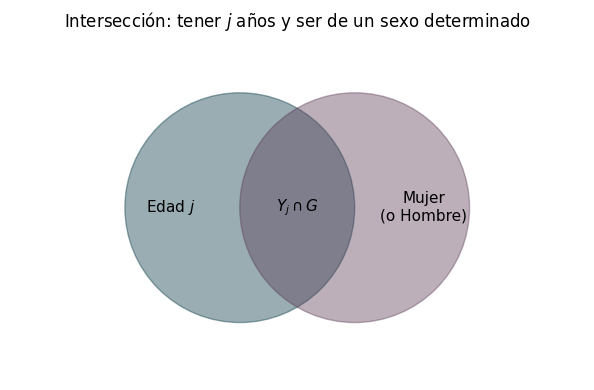

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.axis('off')

circulo_edad = mpatches.Circle((4, 3), 2, color='#013440', alpha=0.4)
circulo_sexo = mpatches.Circle((6, 3), 2, color='#593954', alpha=0.4)
ax.add_patch(circulo_edad)
ax.add_patch(circulo_sexo)

ax.text(2.8, 3, 'Edad $j$', ha='center', va='center', fontsize=11)
ax.text(7.2, 3, 'Mujer\n(o Hombre)', ha='center', va='center', fontsize=11)
ax.text(5, 3, '$Y_j \\cap G$', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Intersección: tener $j$ años y ser de un sexo determinado', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
porcentaje_mujeres = (
    tabla.loc[tabla.index != "All", "Mujer"] 
    / tabla.loc["All", "Mujer"] 
    * 100
)

porcentaje_mujeres

P03
0      1.365746
1      1.339774
2      1.450993
3      1.540408
4      1.595759
         ...   
116    0.000012
117    0.000000
118    0.000023
119    0.000000
120    0.000023
Name: Mujer, Length: 120, dtype: float64